In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
df = pd.read_csv('../data/student_performance_dataset.csv')
print("Data loaded successfully. Shape:", df.shape)
print(df)

Data loaded successfully. Shape: (100, 13)
   student_id      name  study_hours  attendance_percentage  previous_marks  \
0        S001   Vikram1          8.8                     90              85   
1        S002    Arjun2          8.0                     70              93   
2        S003    Priya3          4.6                     64              40   
3        S004    Sneha4          2.5                     99              87   
4        S005    Sneha5          5.3                     95              83   
..        ...       ...          ...                    ...             ...   
95       S096   Rohan96          6.6                     69              62   
96       S097   Rohan97          9.1                     92              81   
97       S098   Rohan98          3.2                     80              66   
98       S099   Rahul99          2.7                     83              67   
99       S100  Rohan100          5.2                     81              73   

    assi

In [4]:
# Handle missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Create features (X) and target (y)
feature_columns = ['study_hours', 'attendance', 'previous_marks', 
                   'assignment_completion', 'sleep_hours', 'participation', 
                   'internet_usage', 'parent_education']

In [7]:
feature_columns = [
	'study_hours',
	'attendance_percentage',
	'previous_marks',
	'assignments_completed',
	'sleep_hours',
	'activity_participation',
	'internet_usage_hours'
]
y = df['performance_score']  # Regression task

# Split data
X = df[feature_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 80
Testing set size: 20


In [8]:
 #Dictionary to store models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}


In [9]:
#  Dictionary to store results
results = {}

print("MODEL TRAINING AND EVALUATION")

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    if name == 'XGBoost':
        model.fit(X_train, y_train)  # XGBoost can handle unscaled data well
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    


MODEL TRAINING AND EVALUATION

Training Linear Regression...

Training Decision Tree...

Training Random Forest...

Training XGBoost...


In [10]:
  
    # Cross-validation score
if name == 'XGBoost':
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
else:
        X_scaled = scaler.fit_transform(X)
        cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    
results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2_Score': r2,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    }
    
print(f"  MAE: {mae:.2f}")
print(f"  MSE: {mse:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  R² Score: {r2:.4f}")
print(f"  Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

  MAE: 6.28
  MSE: 59.00
  RMSE: 7.68
  R² Score: 0.2606
  Cross-validation R²: 0.3842 (+/- 0.2377)


In [20]:
# Compare models
print("MODEL COMPARISON")

comparison_df = pd.DataFrame(results).T
print(comparison_df.round(4))

# Select the best model (highest R² score)
best_model_name = comparison_df['R2_Score'].idxmax()
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"R² Score: {comparison_df.loc[best_model_name, 'R2_Score']:.4f}")

MODEL COMPARISON
            MAE      MSE   RMSE  R2_Score  CV_Mean  CV_Std
XGBoost  6.2797  58.9971  7.681    0.2606   0.3842  0.2377

Best Model: XGBoost
R² Score: 0.2606


In [21]:
# Save the best model and scaler
if best_model_name == 'XGBoost':
    joblib.dump(best_model, 'models/best_model.pkl')
else:
    joblib.dump(best_model, 'models/best_model.pkl')

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(feature_columns, 'models/feature_columns.pkl')

print("\nModel saved successfully!")



Model saved successfully!


In [22]:
# Feature importance analysis for Random Forest/XGBoost
print("FEATURE IMPORTANCE ANALYSIS")

if best_model_name in ['Random Forest', 'XGBoost']:
    if best_model_name == 'Random Forest':
        importance = best_model.feature_importances_
    else:
        importance = best_model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(feature_importance_df)
    

FEATURE IMPORTANCE ANALYSIS

Feature Importance:
                  Feature  Importance
2          previous_marks    0.411722
3   assignments_completed    0.359556
0             study_hours    0.093889
1   attendance_percentage    0.043941
4             sleep_hours    0.035846
6    internet_usage_hours    0.034052
5  activity_participation    0.020993



 Feature importance plot saved!


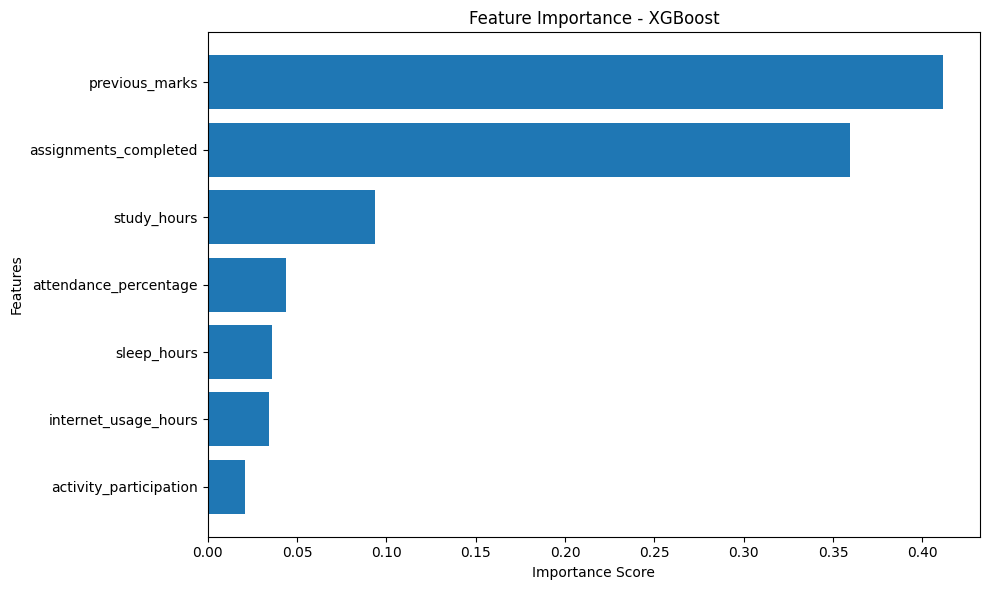

In [25]:
    # Create visualization

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title(f'Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../static/feature_importance.png')
print("\n Feature importance plot saved!")


In [28]:
# Function to predict grade from score
def get_grade(score):
    if score >= 85:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 55:
        return 'C'
    elif score >= 40:
        return 'D'
    else:
        return 'F'

# Test prediction with sample student

print("SAMPLE PREDICTION")


sample_student = {
    'study_hours': 6,
    'attendance': 85,
    'previous_marks': 75,
    'assignment_completion': 80,
    'sleep_hours': 7,
    'participation': 2,
    'internet_usage': 4,
    'parent_education': 2
}

sample_df = pd.DataFrame([sample_student])
sample_df = pd.DataFrame([sample_student]).rename(columns={
	'attendance': 'attendance_percentage',
	'assignment_completion': 'assignments_completed',
	'participation': 'activity_participation',
	'internet_usage': 'internet_usage_hours'
})
sample_df = sample_df[feature_columns]
sample_scaled = scaler.transform(sample_df)
predicted_score = best_model.predict(sample_scaled)[0] if best_model_name != 'XGBoost' else best_model.predict(sample_df)[0]
predicted_grade = get_grade(predicted_score)

print(f"Input Features: {sample_student}")
print(f"Predicted Performance Score: {predicted_score:.2f}")
print(f"Predicted Grade: {predicted_grade}")

SAMPLE PREDICTION
Input Features: {'study_hours': 6, 'attendance': 85, 'previous_marks': 75, 'assignment_completion': 80, 'sleep_hours': 7, 'participation': 2, 'internet_usage': 4, 'parent_education': 2}
Predicted Performance Score: 88.13
Predicted Grade: A
